In [1]:
import tensorflow as tf
import polars as pl
import keras
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.model.layer import gelu_approximate, FeatureWiseScalingLayer, DecompositionLayer
from src.utils.miscellaneous import create_seq_dataset_multiple_input_single_output

2026-01-16 21:42:10.888954: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-16 21:42:10.907993: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768567330.932112  437639 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768567330.940400  437639 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768567330.959090  437639 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
data = pl.read_parquet('dataset.zstd')
dataset = data[['p1_pressure', 'peak_p1_pressure']].to_numpy()
dataset = dataset[::1000]

time_arr = data['time(h)'].to_numpy()[::1000]

dataset.shape

(505826, 2)

In [3]:
seq_len = 360
pred_distance = 360 * 600
target_idx_pos = 1

train_feature, train_target = create_seq_dataset_multiple_input_single_output(dataset, seq_len=seq_len, pred_distance=pred_distance, target_idx_pos=target_idx_pos)

train_target = np.squeeze(train_target)

print(train_feature.shape, train_target.shape)

creating sequence dataset...:   0%|          | 0/289826 [00:00<?, ?it/s]

(289467, 360, 1) (289467,)


In [4]:
time_arr_1 = time_arr[-train_feature.shape[0]:]
time_arr_1.shape

(289467,)

In [5]:
model = keras.models.load_model('model_216000.keras', custom_objects={'gelu_approximate': gelu_approximate,
                                                                       'FeatureWiseScalingLayer': FeatureWiseScalingLayer,
                                                                       'DecompositionLayer': DecompositionLayer})

I0000 00:00:1768567339.232535  437639 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46395 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:4b:00.0, compute capability: 8.6
I0000 00:00:1768567339.234945  437639 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 45964 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:b1:00.0, compute capability: 8.6


In [6]:
train_feature_tensor = tf.data.Dataset.from_tensor_slices(train_feature)
batch_size = 1024*10
train_feature_tensor = train_feature_tensor.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_pred = model.predict(train_feature_tensor)
train_pred = np.squeeze(train_pred)

I0000 00:00:1768567349.993377  438458 service.cc:152] XLA service 0x7db39c0026d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768567349.993431  438458 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1768567349.993449  438458 service.cc:160]   StreamExecutor device (1): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-16 21:42:30.274039: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768567351.763254  438458 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-16 21:42:33.999174: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2033', 236 bytes spill stores, 236 bytes spill loads

2026-01-16 21:42:34.093354: I external/local_xla/xla/stream_executor/cuda/

 3/29 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

I0000 00:00:1768567364.919297  438458 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

2026-01-16 21:42:53.991025: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2049', 372 bytes spill stores, 372 bytes spill loads

2026-01-16 21:42:54.093217: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2049', 360 bytes spill stores, 360 bytes spill loads

2026-01-16 21:42:54.151840: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2049', 232 bytes spill stores, 232 bytes spill loads

2026-01-16 21:42:54.199081: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2049', 432 bytes spill stores, 432 bytes spill loads

2026-01-16 21:42:54.242400: I ex

29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 540ms/step


Text(0, 0.5, 'Pressure(Bar)')

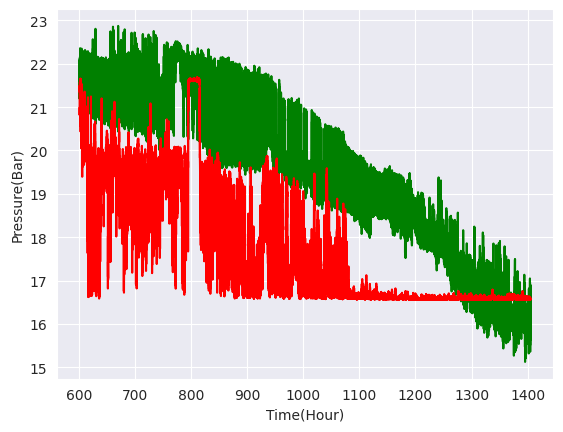

In [7]:
sns.lineplot(x=time_arr_1, y=train_target, color='green')
sns.lineplot(x=time_arr_1, y=train_pred, color='red')

plt.xlabel('Time(Hour)')
plt.ylabel('Pressure(Bar)')